In [21]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [22]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
TRAINING_DIR = DATA_DIR / "training"
MODELS_DIR = PROJECT_ROOT / "models"

In [23]:
test_data = pd.read_csv(
    TRAINING_DIR / "candidate_job_test.csv"
)

logistic_model = joblib.load(
    MODELS_DIR / "logistic_match_model.pkl"
)

random_forest_model = joblib.load(
    MODELS_DIR / "random_forest_match_model.pkl"
)

scaler = joblib.load(
    MODELS_DIR / "feature_scaler.pkl"
)

print("Test data shape:", test_data.shape)
print("Models loaded successfully.")

Test data shape: (1000, 13)
Models loaded successfully.


In [24]:
features = [
    "candidate_experience_years",
    "candidate_skill_count",
    "expected_experience_years",
    "experience_gap",
    "experience_fit",
    "job_skill_count",
    "matched_skill_count",
    "job_skill_coverage",
    "candidate_skill_coverage",
    "role_match_score",
    "job_remote_hint",
    "semantic_similarity"
]

X_test = test_data[features]
y_test = test_data["match_label"]

X_test_scaled = scaler.transform(X_test)

print("X test shape:", X_test.shape)
print("Y test shape:", y_test.shape)

X test shape: (1000, 12)
Y test shape: (1000,)


In [25]:
logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [26]:
def evaluate_model(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1 Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

In [27]:
logistic_metrics = evaluate_model(
    y_test,
    logistic_predictions,
    logistic_probabilities
)

rf_metrics = evaluate_model(
    y_test,
    rf_predictions,
    rf_probabilities
)

print("Logistic Regression:")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print()

print("Random Forest:")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression:
Accuracy: 0.8240
Precision: 0.7520
Recall: 0.6167
F1 Score: 0.6777
ROC-AUC: 0.8953

Random Forest:
Accuracy: 0.8360
Precision: 0.6889
Recall: 0.8267
F1 Score: 0.7515
ROC-AUC: 0.8972


In [28]:
comparison = pd.DataFrame(
    [logistic_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"]
)

comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.824,0.752033,0.616667,0.677656,0.895257
Random Forest,0.836,0.688889,0.826667,0.751515,0.897160


In [29]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print(logistic_cm)

[[639  61]
 [115 185]]


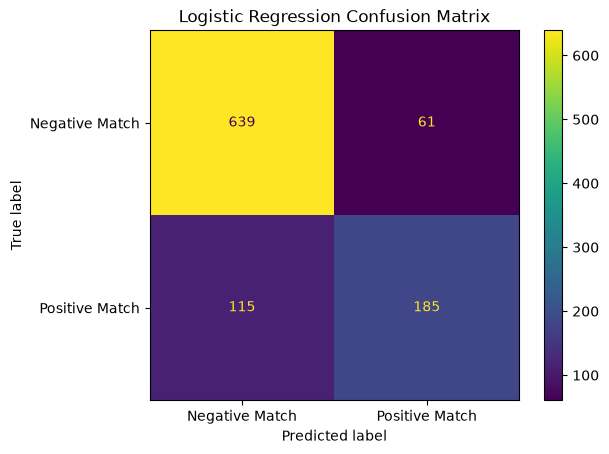

In [30]:
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Negative Match", "Positive Match"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [31]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(rf_cm)

[[588 112]
 [ 52 248]]


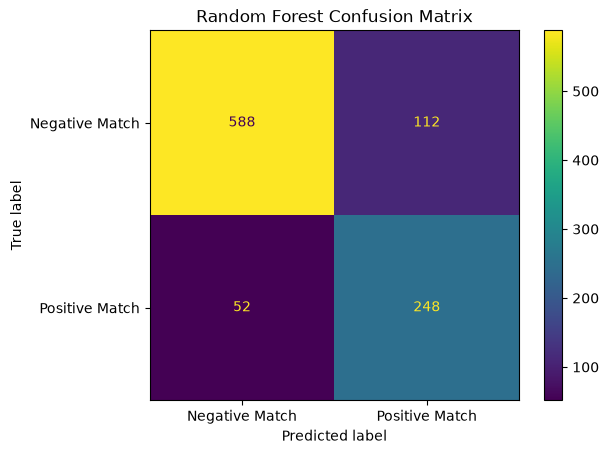

In [32]:
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Negative Match", "Positive Match"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [33]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

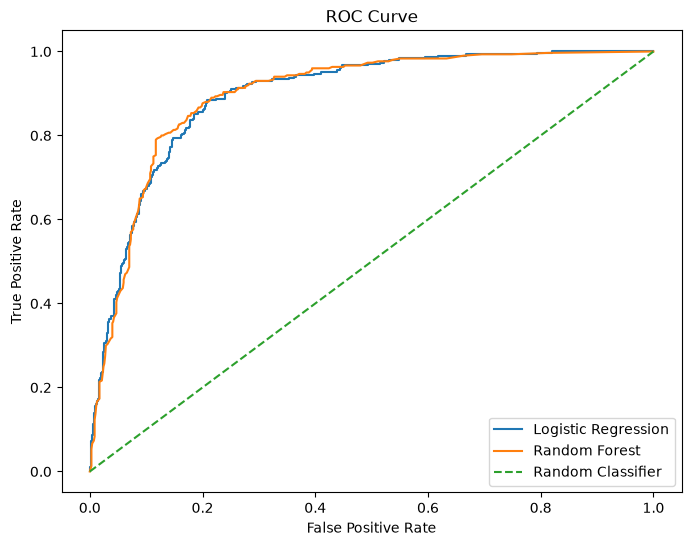

In [34]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
7,job_skill_coverage,0.205862
11,semantic_similarity,0.188749
8,candidate_skill_coverage,0.130358
5,job_skill_count,0.111916
6,matched_skill_count,0.089779
9,role_match_score,0.077517
3,experience_gap,0.050156
0,candidate_experience_years,0.047819
1,candidate_skill_count,0.045891
2,expected_experience_years,0.026855


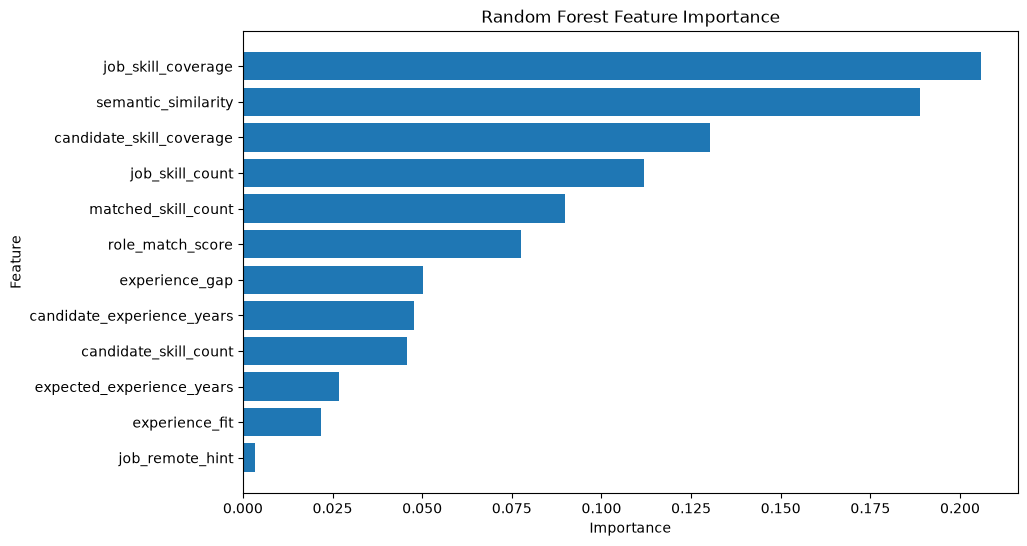

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [37]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": logistic_model.coef_[0]
})

coefficients["absolute_coefficient"] = (
    coefficients["coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "absolute_coefficient",
    ascending=False
)

coefficients

,feature,coefficient,absolute_coefficient
6,matched_skill_count,0.958270,0.958270
8,candidate_skill_coverage,0.766004,0.766004
5,job_skill_count,-0.742076,0.742076
11,semantic_similarity,0.609375,0.609375
9,role_match_score,0.352486,0.352486
1,candidate_skill_count,0.256831,0.256831
7,job_skill_coverage,-0.243663,0.243663
2,expected_experience_years,0.073792,0.073792
3,experience_gap,-0.054633,0.054633
4,experience_fit,-0.025781,0.025781


In [38]:
probability_comparison = pd.DataFrame({
    "actual": y_test.values,
    "logistic_probability": logistic_probabilities,
    "random_forest_probability": rf_probabilities
})

probability_comparison.head(20)

,actual,logistic_probability,random_forest_probability
0,0,0.031197,0.010
1,1,0.897645,0.765
2,0,0.021968,0.005
3,0,0.664297,0.650
4,0,0.074751,0.005
5,0,0.041670,0.155
6,0,0.043856,0.060
7,0,0.013339,0.000
8,0,0.827120,0.655
9,0,0.123059,0.015


In [39]:
comparison.to_csv(
    MODELS_DIR / "model_comparison.csv"
)

importance.to_csv(
    MODELS_DIR / "random_forest_feature_importance.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.


In [40]:
print("MODEL EVALUATION SUMMARY")


print("\nLogistic Regression")
for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nRandom Forest")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nEvaluation completed successfully.")

MODEL EVALUATION SUMMARY

Logistic Regression
Accuracy: 0.8240
Precision: 0.7520
Recall: 0.6167
F1 Score: 0.6777
ROC-AUC: 0.8953

Random Forest
Accuracy: 0.8360
Precision: 0.6889
Recall: 0.8267
F1 Score: 0.7515
ROC-AUC: 0.8972

Evaluation completed successfully.
